# HoloPaint U-Net Edge Detection — Model Evaluation

This notebook evaluates the trained U-Net model, generates visualizations
for the DL project report, and demonstrates edge detection on custom images.

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms.functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load Trained Model

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class UNetEdgeDetector(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1, self.enc2 = ConvBlock(in_channels, 64), ConvBlock(64, 128)
        self.enc3, self.enc4 = ConvBlock(128, 256), ConvBlock(256, 512)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)
        self.output_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return torch.sigmoid(self.output_conv(d1))

model = UNetEdgeDetector().to(device)
model.load_state_dict(torch.load("../holopaint_unet.pth", map_location=device))
model.eval()
print("Model loaded successfully!")

params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {params:,}")

Model loaded successfully!
Total parameters: 31,037,633


## 2. Training Loss Curves

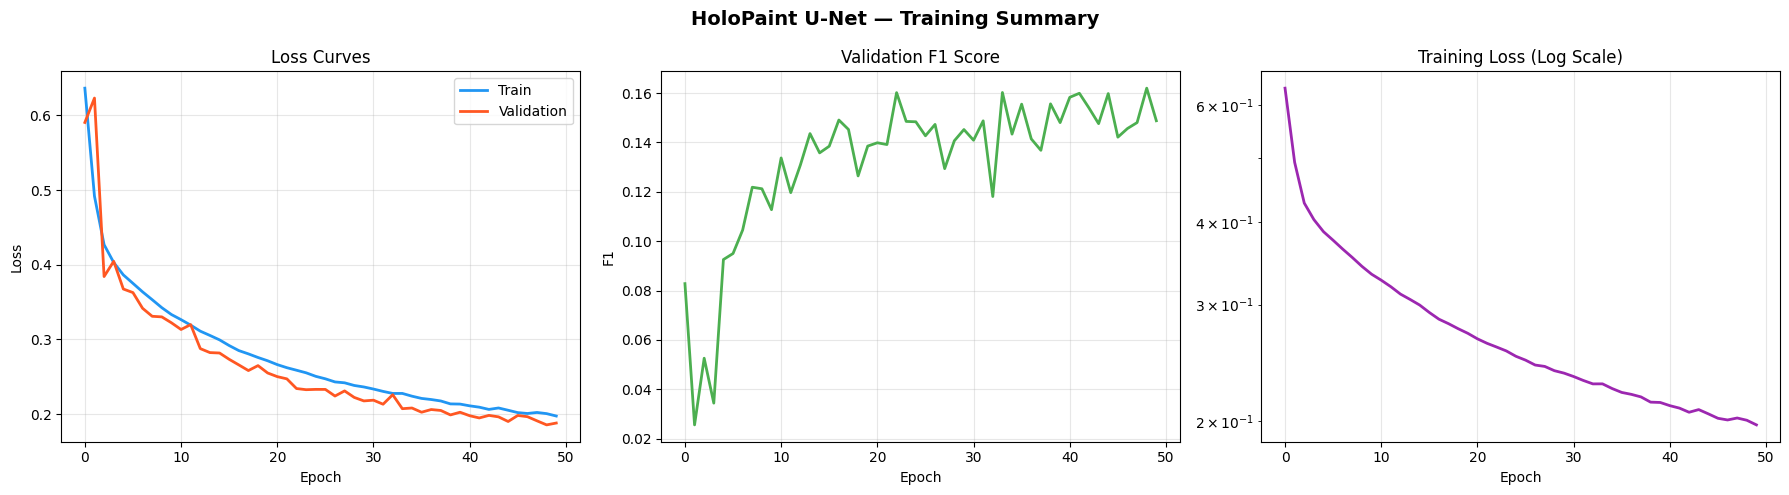

Best validation loss: 0.1856
Final F1 score: 0.1488


In [15]:
log = torch.load("../training_log.pth", map_location="cpu")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(log["train_losses"], label="Train", color="#2196F3", lw=2)
axes[0].plot(log["val_losses"], label="Validation", color="#FF5722", lw=2)
axes[0].set_title("Loss Curves"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(log["val_f1_scores"], color="#4CAF50", lw=2)
axes[1].set_title("Validation F1 Score"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1")
axes[1].grid(True, alpha=0.3)

# Learning rate (inferred from loss drops)
axes[2].semilogy(log["train_losses"], color="#9C27B0", lw=2)
axes[2].set_title("Training Loss (Log Scale)"); axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

plt.suptitle("HoloPaint U-Net — Training Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best validation loss: {log['best_val_loss']:.4f}")
print(f"Final F1 score: {log['val_f1_scores'][-1]:.4f}")

## 3. Test Set Evaluation (Metrics)

In [18]:
from sklearn.metrics import f1_score, precision_score, recall_score
import scipy.io

BSR_DIR = Path("../data/BSR/BSDS500/data")
test_img_dir = BSR_DIR / "images" / "test"
test_gt_dir = BSR_DIR / "groundTruth" / "test"

test_images = sorted(test_img_dir.glob("*.jpg"))
test_gts = sorted(test_gt_dir.glob("*.mat"))

all_preds, all_targets = [], []

for img_path, gt_path in zip(test_images, test_gts):
    image = Image.open(img_path).convert("RGB")
    image = TF.resize(image, [256, 256])
    tensor = TF.to_tensor(image)
    tensor = TF.normalize(tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    with torch.no_grad():
        pred = model(tensor.unsqueeze(0).to(device))

    pred_binary = (pred.squeeze().cpu().numpy() > 0.5).astype(np.float32)

    mat = scipy.io.loadmat(gt_path)
    gt_data = mat["groundTruth"][0]
    edges = np.mean([gt_data[i][0][0][1].astype(np.float32) for i in range(len(gt_data))], axis=0)
    gt_resized = np.array(Image.fromarray((edges > 0.5).astype(np.uint8) * 255).resize((256, 256))) / 255.0

    all_preds.append(pred_binary.flatten())
    all_targets.append(gt_resized.flatten())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

f1 = f1_score(all_targets.round(), all_preds.round(), zero_division=0)
prec = precision_score(all_targets.round(), all_preds.round(), zero_division=0)
rec = recall_score(all_targets.round(), all_preds.round(), zero_division=0)

print("=" * 40)
print("Test Set Evaluation Metrics")
print("=" * 40)
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")

Test Set Evaluation Metrics
  Precision: 0.0577
  Recall:    0.4858
  F1 Score:  0.1031


## 4. Visual Comparison Grid

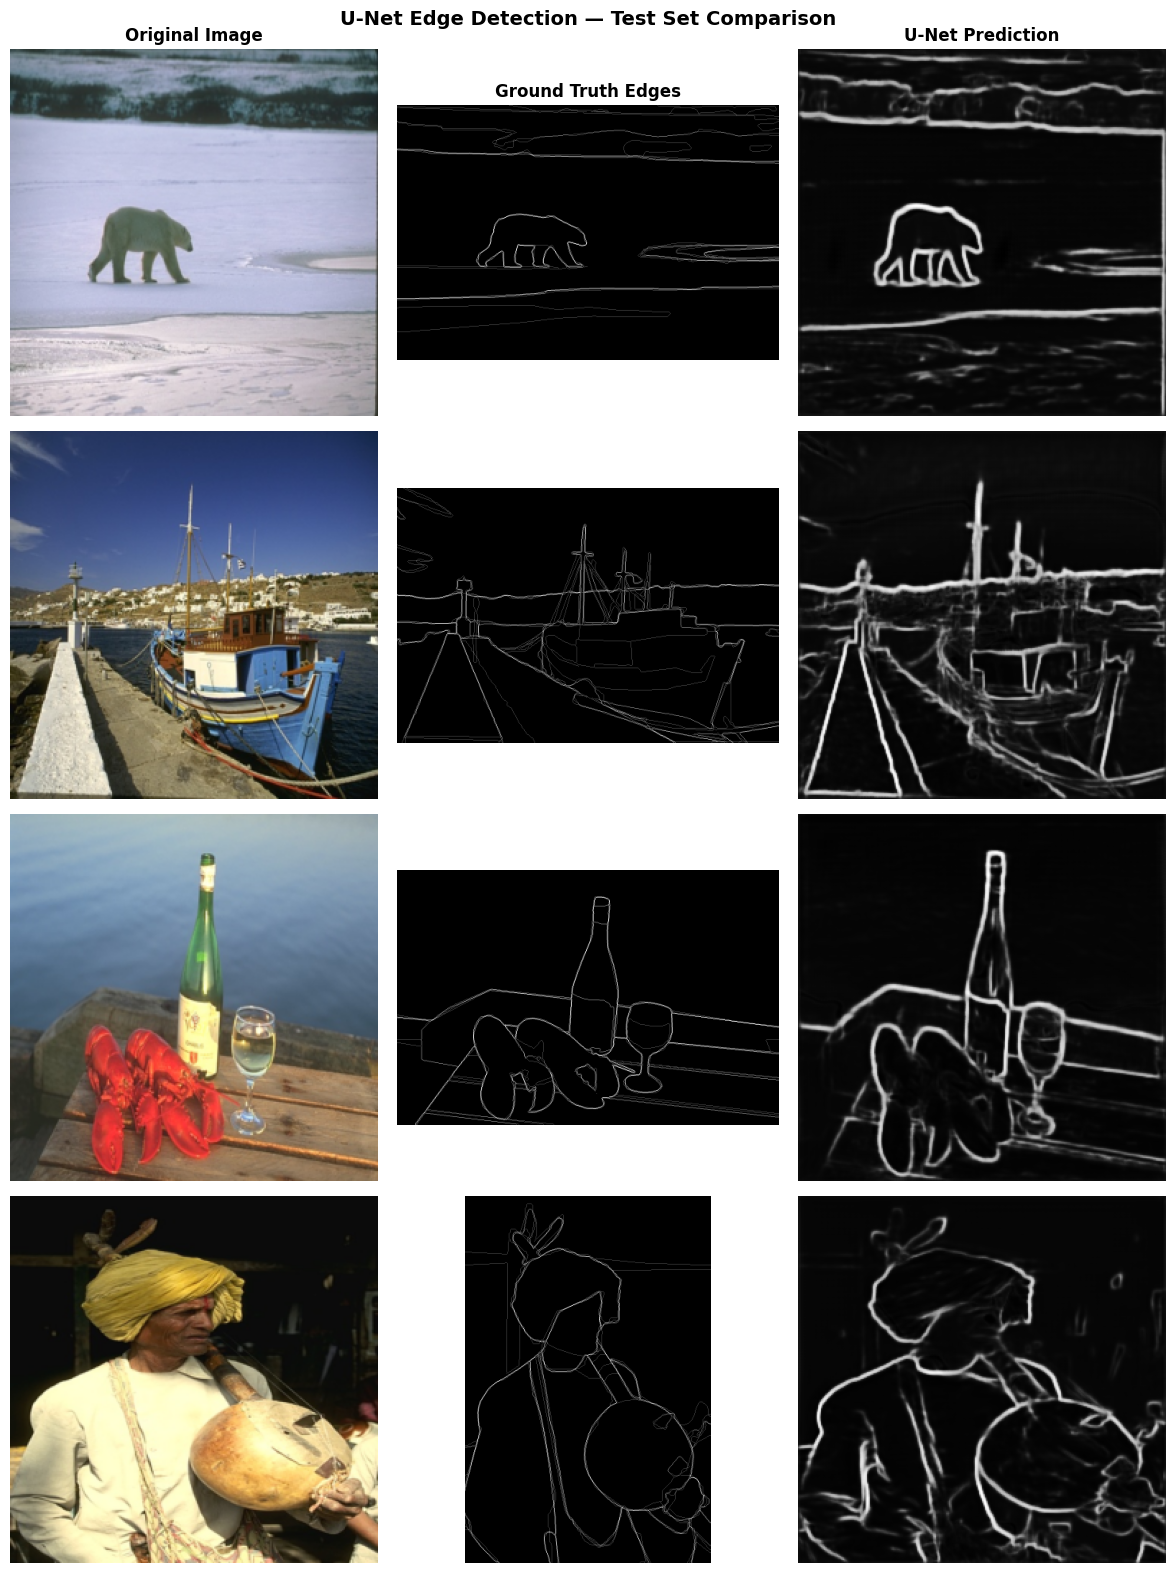

In [19]:
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
cols = ["Original Image", "Ground Truth Edges", "U-Net Prediction"]
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=12, fontweight="bold")

for row in range(4):
    idx = row * 25
    img = Image.open(test_images[idx]).convert("RGB")
    img_resized = TF.resize(img, [256, 256])
    tensor = TF.normalize(TF.to_tensor(img_resized), [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    with torch.no_grad():
        pred = model(tensor.unsqueeze(0).to(device)).squeeze().cpu().numpy()

    mat = scipy.io.loadmat(test_gts[idx])
    gt_data = mat["groundTruth"][0]
    gt_edges = np.mean([gt_data[i][0][0][1].astype(np.float32) for i in range(len(gt_data))], axis=0)

    axes[row, 0].imshow(img_resized); axes[row, 0].axis("off")
    axes[row, 1].imshow(gt_edges, cmap="gray"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred, cmap="gray"); axes[row, 2].axis("off")

plt.suptitle("U-Net Edge Detection — Test Set Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Threshold Analysis

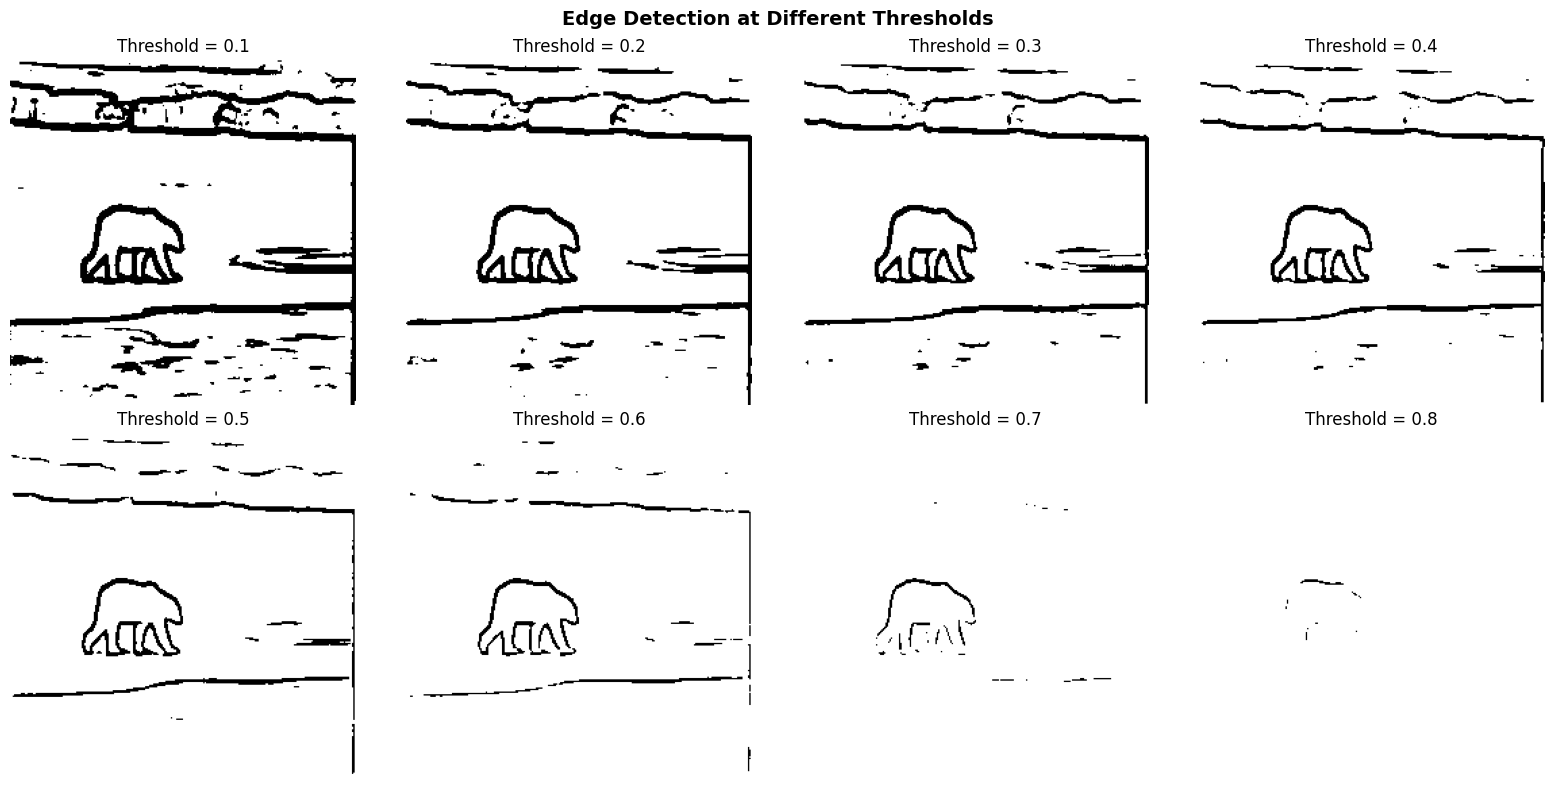

In [20]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
sample_img = Image.open(test_images[0]).convert("RGB")
sample_tensor = TF.normalize(TF.to_tensor(TF.resize(sample_img, [256, 256])),
                              [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
with torch.no_grad():
    pred = model(sample_tensor.unsqueeze(0).to(device)).squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, t in enumerate(thresholds):
    r, c = i // 4, i % 4
    binary = (pred > t).astype(np.float32)
    axes[r, c].imshow(1 - binary, cmap="gray")  # Invert for display
    axes[r, c].set_title(f"Threshold = {t}")
    axes[r, c].axis("off")

plt.suptitle("Edge Detection at Different Thresholds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Map Visualization

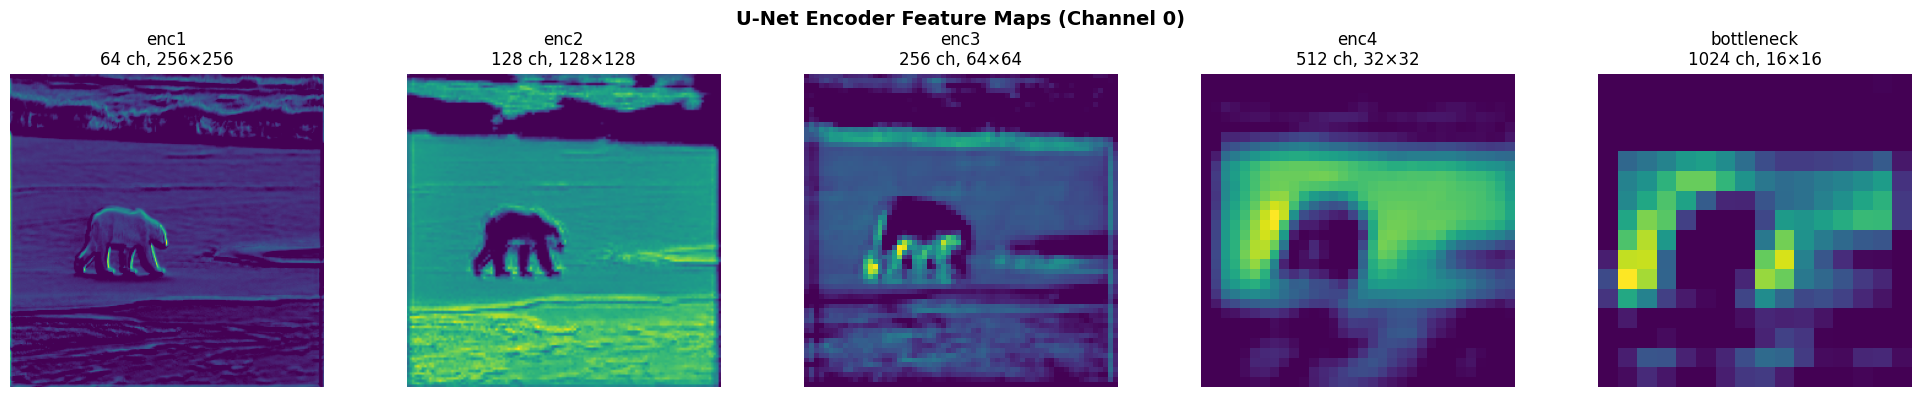


 Evaluation complete! All figures saved.


In [21]:
# Extract intermediate feature maps from encoder layers
activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks
model.enc1.register_forward_hook(hook_fn("enc1"))
model.enc2.register_forward_hook(hook_fn("enc2"))
model.enc3.register_forward_hook(hook_fn("enc3"))
model.enc4.register_forward_hook(hook_fn("enc4"))
model.bottleneck.register_forward_hook(hook_fn("bottleneck"))

# Forward pass
with torch.no_grad():
    _ = model(sample_tensor.unsqueeze(0).to(device))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
layer_names = ["enc1", "enc2", "enc3", "enc4", "bottleneck"]
for i, name in enumerate(layer_names):
    feat = activations[name][0, 0].cpu().numpy()  # First channel
    axes[i].imshow(feat, cmap="viridis")
    axes[i].set_title(f"{name}\n{activations[name].shape[1]} ch, {feat.shape[0]}×{feat.shape[1]}")
    axes[i].axis("off")

plt.suptitle("U-Net Encoder Feature Maps (Channel 0)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_maps.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Evaluation complete! All figures saved.")